In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

In [11]:
df = pd.read_csv("Fact_marketing.csv")
dim_date = pd.read_csv("dim_date.csv")

In [12]:
# vérifier les nulls
print(df.isnull().sum())

# supprimer ou remplacer
df = df.dropna()

marketing_spend      0
new_beneficiaries    0
id_dateFK            0
dtype: int64


In [13]:
df =df.merge(dim_date, left_on='id_dateFK', right_on='id_date')
df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

In [14]:
df.head(5)

,marketing_spend,new_beneficiaries,id_dateFK,id_date,Date,Day,Month,Year,month,year
0,29217,1568,8339,8339,2023-01-31,31,1,2023,1,2023
1,142420,1166,8367,8367,2023-02-28,28,2,2023,2,2023
2,24307,1488,8398,8398,2023-03-31,31,3,2023,3,2023
3,28777,745,8428,8428,2023-04-30,30,4,2023,4,2023
4,18688,1540,8459,8459,2023-05-31,31,5,2023,5,2023


In [16]:
df=df.drop(columns=['id_dateFK','id_date','Day','Month','Year','month','year'])

In [17]:
df.head(5)

,marketing_spend,new_beneficiaries,Date
0,29217,1568,2023-01-31
1,142420,1166,2023-02-28
2,24307,1488,2023-03-31
3,28777,745,2023-04-30
4,18688,1540,2023-05-31


In [19]:
X = df[['marketing_spend']]
y = df['new_beneficiaries']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

linear_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [23]:
ridge_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

In [24]:
rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error

def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return [name, mse, rmse, mae, r2]

results = []
results.append(evaluate(y_test, y_pred_linear, "Linear"))
results.append(evaluate(y_test, y_pred_ridge, "Ridge"))
results.append(evaluate(y_test, y_pred_rf, "Random Forest"))

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "MAE", "R2"])
print(results_df)

           Model            MSE        RMSE         MAE        R2
0         Linear  231835.015054  481.492487  384.933927 -0.596257
1          Ridge  231366.999401  481.006236  384.812129 -0.593035
2  Random Forest  109071.404578  330.259602  301.960625  0.249009


In [28]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear": linear_model,
    "Ridge": ridge_model,
    "RF": rf_model
}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=kf,
                            scoring=('neg_mean_squared_error', 'r2'))

    mse = -scores['test_neg_mean_squared_error'].mean()
    rmse = np.sqrt(mse)
    r2 = scores['test_r2'].mean()

    print(f"{name} → RMSE: {rmse:.2f}, R2: {r2:.2f}")

Linear → RMSE: 630.82, R2: -0.38
Ridge → RMSE: 628.15, R2: -0.37
RF → RMSE: 609.09, R2: -0.14


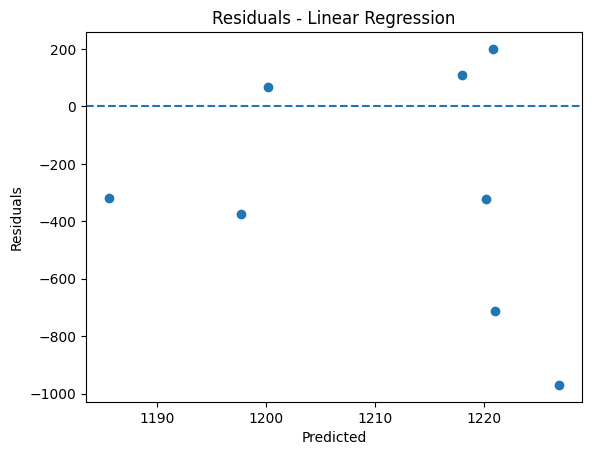

In [29]:
residuals = y_test - y_pred_linear

plt.scatter(y_pred_linear, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals - Linear Regression")
plt.show()

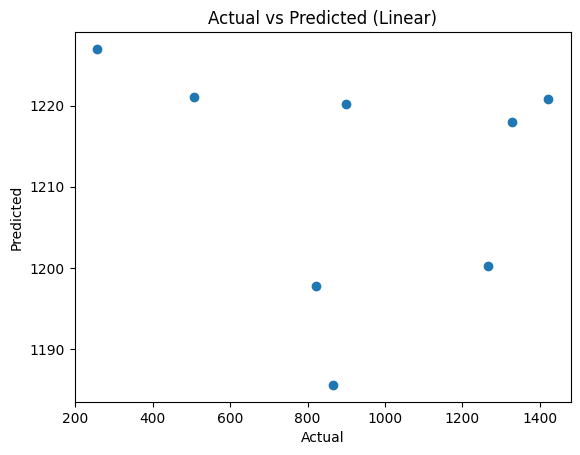

In [30]:
plt.scatter(y_test, y_pred_linear)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear)")
plt.show()

In [31]:
coef = linear_model.named_steps['model'].coef_
print("Coefficient (spending):", coef)

Coefficient (spending): [-42.58055598]


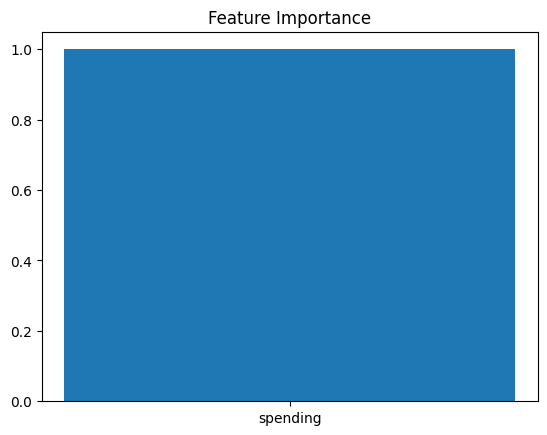

In [32]:
importance = rf_model.named_steps['model'].feature_importances_

plt.bar(["spending"], importance)
plt.title("Feature Importance")
plt.show()

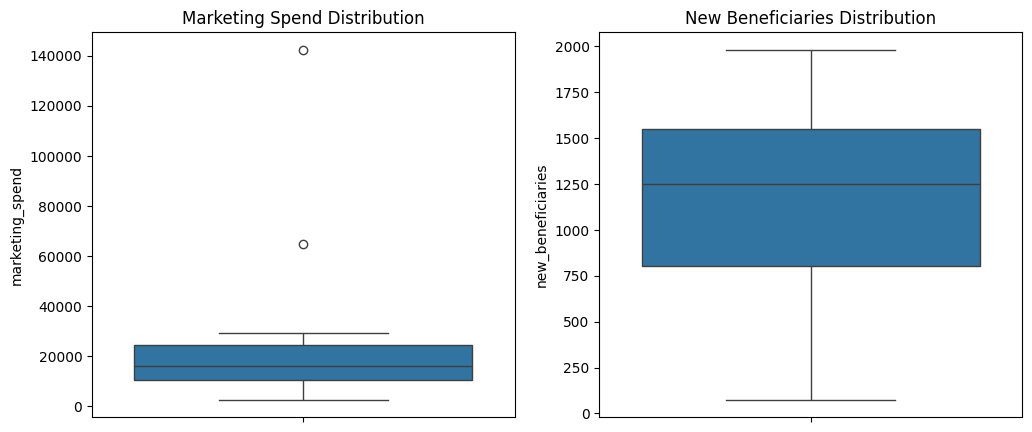

In [36]:
import seaborn as sns

# =========================
# BOXPLOT - SEABORN STYLE
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['marketing_spend'])
plt.title("Marketing Spend Distribution")

plt.subplot(1,2,2)
sns.boxplot(y=df['new_beneficiaries'])
plt.title("New Beneficiaries Distribution")

plt.show()